In [ ]:
# %reload_ext postcell
# %postcell register

# Ray - a Python framework for **distributed** computation

Definition of a distributed system: 

_"Where a computer that you never heard of can bring your system down"_ -- Leslie Lamport

_"Distributed computing: the cause of, and solution to, the world's tech problems"_ - My take on a famous quote from Homer Simpson about alcohol

### Types of distributed computing
Distributed systems are necessary for many reasons. We look at a few below.

For the purpose of data science and machine learning, we start with three compoents: computer of a certain size, model of a certain size and data of a certain size:

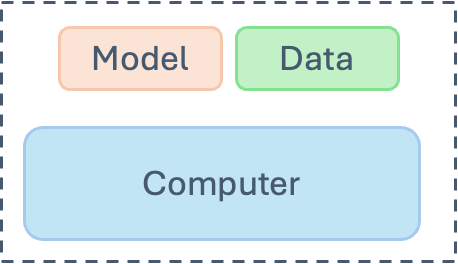


#### Task Prallelism

Imagine training a medium size model, such as a support vector machine, on a medium size dataset. Both can fit in your computer's memory. If you want to do train a number of models (perhaps for hyper parameter tuning), your standard Python loop will train one model at a time. 

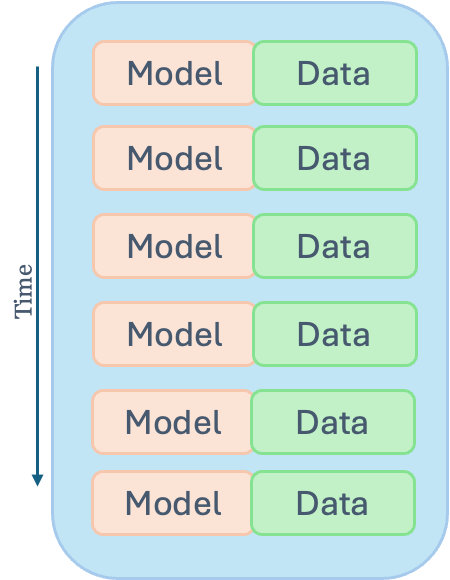

Why not do this in parallel, across all your CPU cores? Even better, why not distribute it across a cluster of machines?


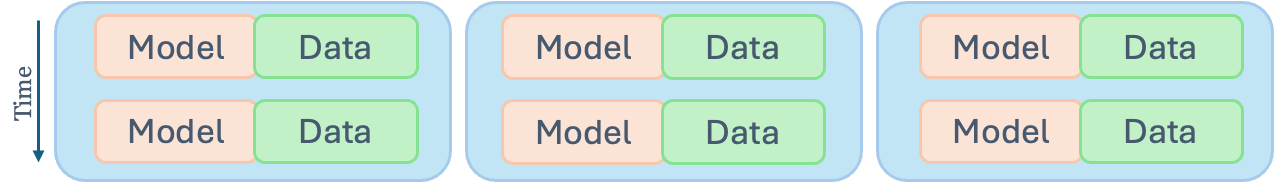


#### Data/Model Parallelism

What if your data is simply too large to fit into memory? For example, if you want to process 10 thousand medical images, they may simply not fit on to a single computer. On the other hand, if you are trying to fit a large langiage model on a laptop, it may simple be too large. What will you do then?

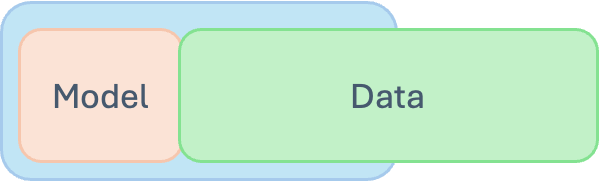

You can split data into subsets, commonly caled "data sharding"  
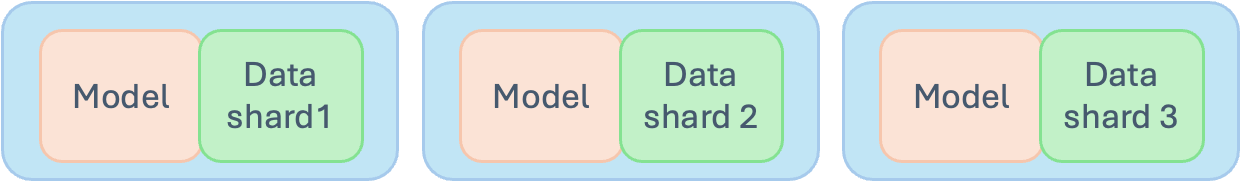


Similarly, if your model is too large for a single machine, there are various model specific techniques to split your model across multiple machines.

Additionally, distributed computing is concerned with fault tolerence, resource allocation and other operational matters. Some of these were covered in the Kubernetes lecture.

In this lecture, we will concentrate only on **task** parallelism.

 ### Problem: Python is mostly single threaded

 Let's take a quick look at carrying out a common Python tasks:

In [ ]:
import os
import socket
import time
import warnings
import joblib

import numpy as np
import pandas as pd

from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.datasets import make_classification
from sklearn.exceptions import ConvergenceWarning

In [ ]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)

#### Train a model and watch cpu usage
Notice that only one core is being used at a time

Generate data for processing

In [ ]:
X, y = make_classification(n_samples=100_000, n_features=100)

This function trains an SVC model for different values of the `gamma` parameter

In [ ]:
def ml_run(g, X, y):
    model = SVC(kernel='rbf', C=1000, gamma=g, max_iter=1_000)
    score = cross_val_score(model, X, y, cv=3).mean()

    # Cluster info
    host = socket.gethostname()
    pid = os.getpid()

    return score, g, host, pid

Train the function for different values of `gamma`

In [ ]:
%%time
gamma_params = [3, 5, 10]

# Pretend GridSearch doesn't exist
train_results = [ml_run(g, X, y) for g in gamma_params]

pd.DataFrame(train_results, columns=['score', 'gamma', 'hostname', 'pid'])

Let's try proper GridSearch, which uses the _Joblib_ library

In [ ]:
%%time
grid_search = GridSearchCV(
    estimator=SVC(kernel='rbf', C=1000, max_iter=1_000),
    param_grid={'gamma': [3, 5, 10]},
    cv=3,
    scoring='accuracy',
    n_jobs=-1 # Uses all your CPU cores to speed it up!
).fit(X, y)

We see a speedup and more effecient use of our laptop's resources!
We can go one step further and actually distribute the computation across a cluster, rather than just a single machine.

### Use Ray to distribute computation across your cores
Even if `GridSearchCV` didn't exist, we could have used the Ray library to distribute the computation

In [ ]:
import ray
from ray.util.joblib import register_ray

Start a local Ray instance. This will distributed code across cpu cores (but not across machines)

In [ ]:
if not ray.is_initialized():
    ray.init(runtime_env={"env_vars": {"PYTHONWARNINGS": "ignore"}})


Ray provides a web based dashboard:
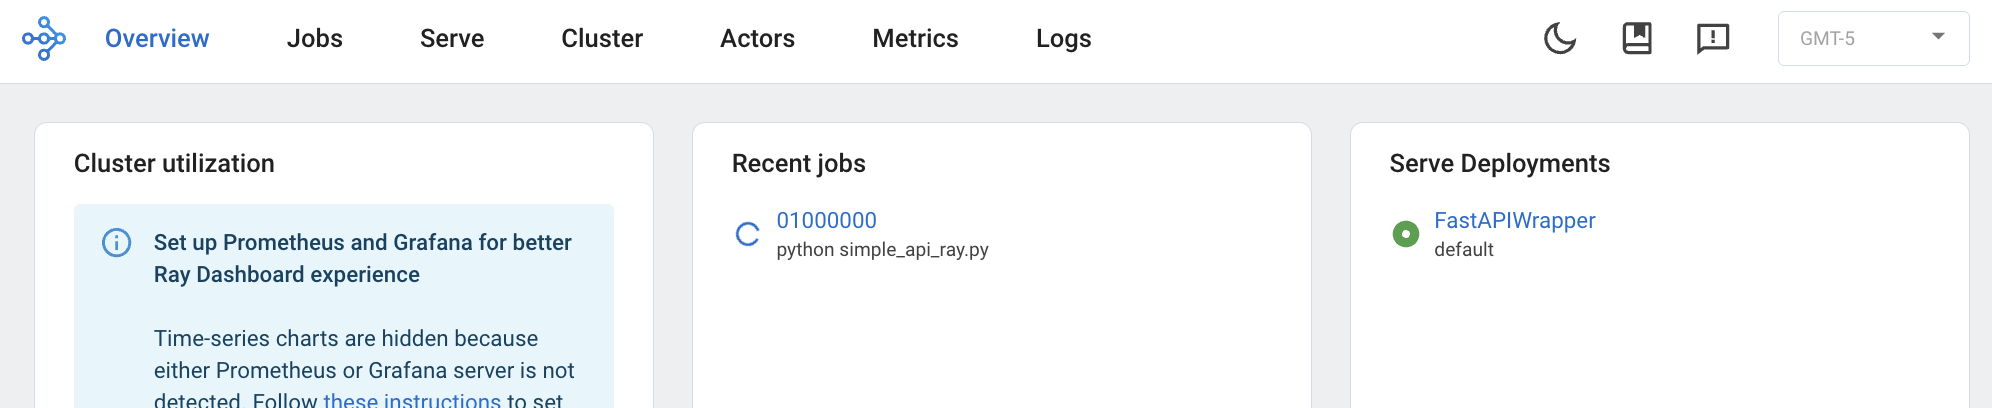

Reminder, this was the original model training function:
```python
def ml_run(g, X, y):
    model = SVC(kernel='rbf', C=1000, gamma=g, max_iter=1_000)
    score = cross_val_score(model, X, y, cv=3).mean()

    # Cluster info
    host = socket.gethostname()
    pid = os.getpid()

    return score, g, host, pid
```

The function `ml_run_parallel` is _exactly_ the same, except it has been annotated with `@ray.remote`

In [ ]:
@ray.remote
def ml_run_parallel(g, X, y):
    from sklearn.svm import SVC
    from sklearn.model_selection import cross_val_score

    model = SVC(kernel='rbf', C=1000, gamma=g, max_iter=1_000)
    score = cross_val_score(model, X, y, cv=3).mean()

    # Cluster info
    host = socket.gethostname()
    pid = os.getpid()

    return score, g, host, pid

In [ ]:
%%time
gamma_params = [3, 5, 10]

# Put X and y into Ray's distributed object store once,
# so they are efficiently shared across all remote workers
X_ref = ray.put(X)
y_ref = ray.put(y)

results = ray.get([ml_run_parallel.remote(g, X_ref, y_ref) for g in gamma_params])

pd.DataFrame(results, columns=['score', 'gamma', 'hostname', 'pid'])

In [ ]:
# Let's clean up the cluster
ray.shutdown()

**Exercise**: Write a remote function which accepts a name and prints a greeting for that name. This function should also print the host and PID inside the function.

In [ ]:
#%%postcell exercise_130_110_a

# Type your answer here

### Use Ray to distribute across _many machines_

Let's set up a fake cluster of 6 machines using docker. 
The `docker-compose.yaml` file in `ray_cluster/` allows us to easily set up a cluster.

Start the virtual cluster
```bash
cd ray_cluster

docker compose up
```

In [ ]:
# if not ray.is_initialized():
#     ray.shutdown()

if not ray.is_initialized():
    ray.init(address="ray://localhost:10001")
    
#print(ray.cluster_resources())

Same code as before, but now running on a (simulated) cluster.
Monitor the cpu via `docker compose stats` or `ctop` (installable via `brew install ctop`)

In [ ]:
%%time
gamma_params = [3, 5, 10]

# Put X and y into Ray's distributed object store once,
# so they are efficiently shared across all remote workers
X_ref = ray.put(X)
y_ref = ray.put(y)

results = ray.get([ml_run_parallel.remote(g, X_ref, y_ref) for g in gamma_params])
pd.DataFrame(results, columns=['score', 'gamma', 'hostname', 'pid'])

If you are getting a 'No module named' error, it is likely because there is a library version mismatch.

In [ ]:
# Cleanup
ray.shutdown()

### Ray as a foundation layer
Ray is becoming a foundational layer for modern ML systes. Many other distributed frameworks now sit on top of Ray. For example, there are projects to distributed [Pandas on Ray](https://docs.ray.io/en/latest/ray-more-libs/modin/index.html), [Dask on Ray](https://docs.ray.io/en/latest/ray-more-libs/dask-on-ray.html), even [Spark on Ray](https://docs.ray.io/en/latest/ray-more-libs/raydp.html).

Ray is currently being used by cutting edge LLM companies:

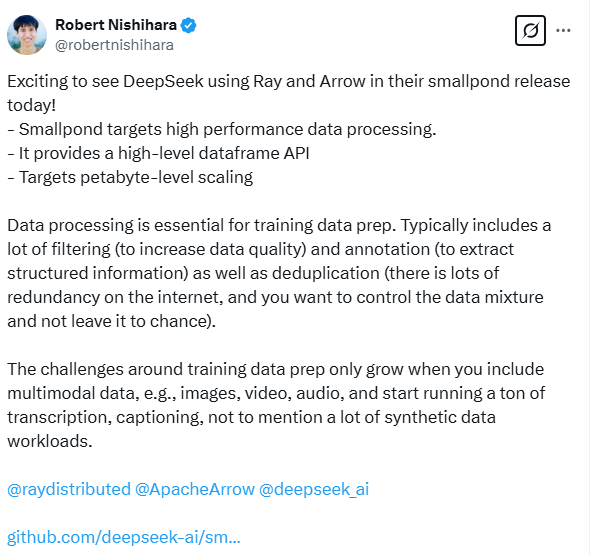

### A project idea: Use idle corporate computers for compute
Large corporations and even small teams have loads of compute, in the form of unused laptops during off hours. Modern Macs even have powerful GPUs built into them.

An interesting experiment would be to run Docker based Ray nodes on these laptops, connected by a VPN, such as Tailnet or NetBird. After office hours, tasks could be distributed across these machines. Keeping the nodes in Docker will keep hostile tasks from causing havoc on host laptops.

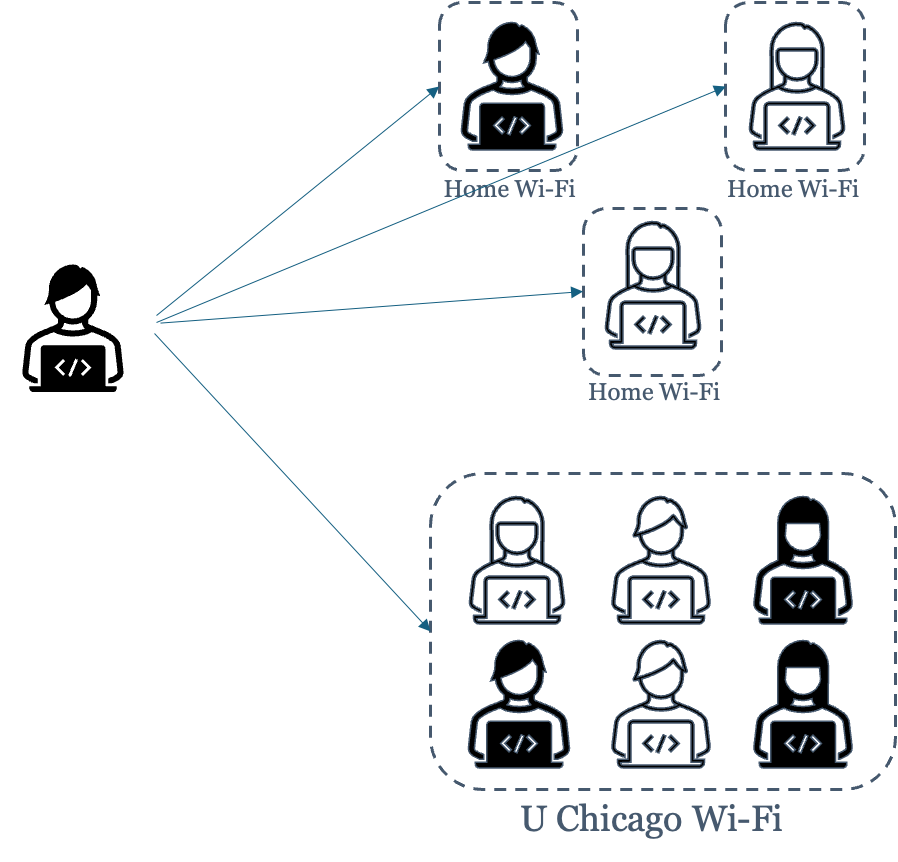


## DEBUG

In [ ]:
@ray.remote
def check_version():
    import numpy as np2
    print(np2.__version__)

In [ ]:
ray.get(check_version.remote())